In [ ]:
# --- Project imports --- #
# Add the 'src' directory to the Python path
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))
# Local module imports
from models.resnet50 import build_model
from utils.utils import load_image_datasets, apply_mixup
from metrics.classification import SparseMacroF1  # custom metric

# --- Third-party libraries --- #
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

In [ ]:
dataset_path = PROJECT_ROOT / "data"

train_dataset, validation_dataset, test_dataset = load_image_datasets(dataset_path)

# --- Inspect class mapping --- #
class_names = train_dataset.class_names
class_to_idx = {name: i for i, name in enumerate(class_names)}

# --- Normalize datasets --- #
# train_dataset = train_dataset.map(lambda x, y: (x / 255.0, y))
# validation_dataset = validation_dataset.map(lambda x, y: (x / 255.0, y))
# test_dataset = test_dataset.map(lambda x, y: (x / 255.0, y))

# --- Apply MixUp to generate interpolated training samples --- #
# train_dataset = train_dataset.map(apply_mixup, num_parallel_calls=tf.data.AUTOTUNE)
# train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
# validation_dataset = validation_dataset.prefetch(tf.data.AUTOTUNE)

print("Class mapping:", class_to_idx)

# Inspect first batch
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Batch size:", labels.shape)


In [ ]:
# model = build_model(num_classes=23, trainable_layers=60)

# # --- Compile --- #
# model.compile(
#     optimizer=Adam(learning_rate=1e-3),
#     loss="sparse_categorical_crossentropy",
#     metrics=[SparseMacroF1(num_classes=23)],
# )
# from tensorflow.keras.callbacks import CSVLogger

# csv_logger = CSVLogger("training_log.csv", append=True)

# # --- Train --- #
# history = model.fit(
#     train_dataset,
#     validation_data=validation_dataset,
#     epochs=30,
#     callbacks=[csv_logger],
# )

In [ ]:
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# --- Build model with frozen backbone for stage 1 --- #
model = build_model(num_classes=23, trainable_layers=0)

# --- Callbacks --- #
callbacks = [
    CSVLogger("training_log.csv", append=True),
    EarlyStopping(
        monitor="val_macro_f1",
        mode="max",
        patience=5,
        restore_best_weights=True,
    ),
    ModelCheckpoint(
        "best_model.keras",
        monitor="val_macro_f1",
        mode="max",
        save_best_only=True,
    ),
]

# --- Stage 1: train classifier head only --- #
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[SparseMacroF1(num_classes=23)],
)

history_stage_1 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=8,
    callbacks=callbacks,
)

# --- Locate ResNet backbone inside the model --- #
base_model = None
for layer in model.layers:
    if "resnet" in layer.name.lower():
        base_model = layer
        break

if base_model is None:
    raise ValueError("ResNet backbone not found inside the model.")

# --- Stage 2: fine-tune top layers of the backbone --- #
base_model.trainable = True

# Freeze all but the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

# --- Recompile with lower learning rate for fine-tuning --- #
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=[SparseMacroF1(num_classes=23)],
)

history_stage_2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=callbacks,
)

# --- Combine histories if you want a single plotting object --- #
history = {
    "loss": history_stage_1.history["loss"] + history_stage_2.history["loss"],
    "val_loss": history_stage_1.history["val_loss"] + history_stage_2.history["val_loss"],
    "macro_f1": history_stage_1.history["macro_f1"] + history_stage_2.history["macro_f1"],
    "val_macro_f1": history_stage_1.history["val_macro_f1"] + history_stage_2.history["val_macro_f1"],
}

Epoch 1/8


In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 23)        │     11,799 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 55,670,727 (212.37 MB)

 Trainable params: 15,511,063 (59.17 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

 Optimizer params: 31,022,128 (118.34 MB)

In [28]:
import pandas as pd

df = pd.DataFrame(history_dict)
df.to_csv("./results/history3.csv", index=False)

In [26]:
df.shape

(18, 4)

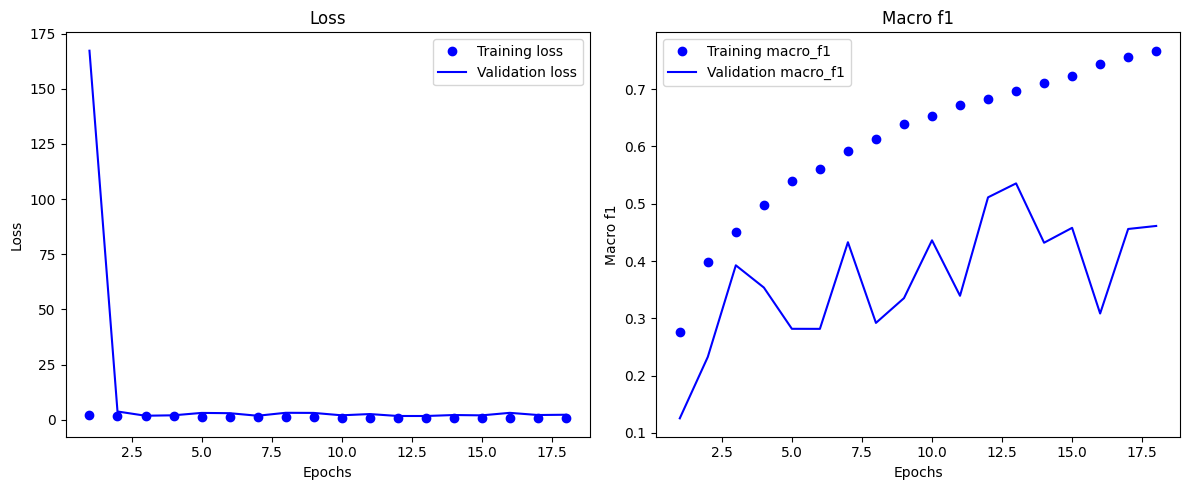

In [16]:
history_dict1 = history_stage_1.history

# Loss metrics
loss_values = history_dict1["loss"]
val_loss_values = history_dict1["val_loss"]
# Accuracy metrics
acc = history_dict1["macro_f1"]
val_acc = history_dict1["val_macro_f1"]

epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=(12, 5))

# Loss subplot
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy subplot
plt.subplot(1, 2, 2)
plt.plot(epochs, acc, "bo", label="Training macro_f1")
plt.plot(epochs, val_acc, "b", label="Validation macro_f1")
plt.title("Macro f1")
plt.xlabel("Epochs")
plt.ylabel("Macro f1")
plt.legend()

plt.tight_layout()
plt.show()


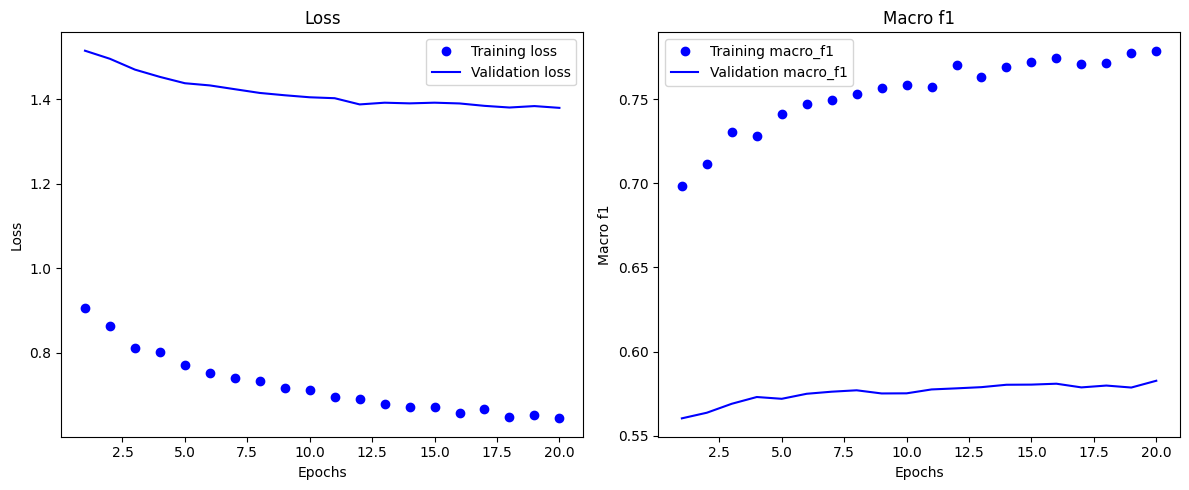

In [17]:
history_dict2 = history_stage_2.history

# Loss metrics
loss_values = history_dict2["loss"]
val_loss_values = history_dict2["val_loss"]
# Accuracy metrics
acc = history_dict2["macro_f1"]
val_acc = history_dict2["val_macro_f1"]

epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=(12, 5))

# Loss subplot
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy subplot
plt.subplot(1, 2, 2)
plt.plot(epochs, acc, "bo", label="Training macro_f1")
plt.plot(epochs, val_acc, "b", label="Validation macro_f1")
plt.title("Macro f1")
plt.xlabel("Epochs")
plt.ylabel("Macro f1")
plt.legend()

plt.tight_layout()
plt.show()


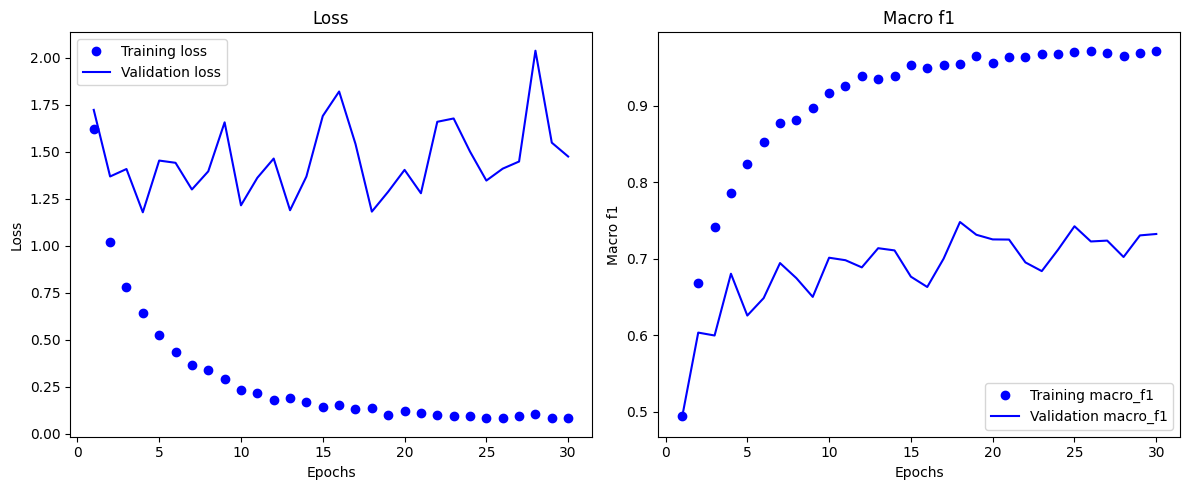

In [8]:
history_dict = history.history

# Loss metrics
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
# Accuracy metrics
acc = history_dict["macro_f1"]
val_acc = history_dict["val_macro_f1"]

epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=(12, 5))

# Loss subplot
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy subplot
plt.subplot(1, 2, 2)
plt.plot(epochs, acc, "bo", label="Training macro_f1")
plt.plot(epochs, val_acc, "b", label="Validation macro_f1")
plt.title("Macro f1")
plt.xlabel("Epochs")
plt.ylabel("Macro f1")
plt.legend()

plt.tight_layout()
plt.show()
